In [1]:
import sys
from pathlib import Path
import inspect
import json
import numpy as np
import pandas as pd
import anndata as ad
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import torch
from matplotlib.patches import Patch
from scipy.spatial import cKDTree
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import connected_components
SOURCE=Path('/home/xueshuailin/CCC_Phe/V1004/src')
if str(SOURCE) in sys.path: sys.path.remove(str(SOURCE))
sys.path.insert(0,str(SOURCE))
from phenoniche.v1002.lr_atlas import load_lr_atlas, LRAtlas
from phenoniche.v1002.simulation_cells import _side_expression
from phenoniche.v1002.final_model import fit_balanced
from phenoniche.v1004.composition_ccc_hierarchy import build_hierarchical_states
from phenoniche.v1004.radius_context import (
    build_radius_context, radius_composition, aggregate_radius_pairwise_ccc)

ROOT=Path('/data1/xueshuailin/CCC_Phe_Niche')
OUTPUT=SOURCE.parent/'outputs/hbc1_hierarchical_niches_r200'
OUTPUT.mkdir(parents=True,exist_ok=True)
assert all(Path(inspect.getfile(fn)).resolve().is_relative_to(SOURCE)
           for fn in (build_radius_context, radius_composition, aggregate_radius_pairwise_ccc,
                      load_lr_atlas, fit_balanced, build_hierarchical_states))
MICROENV_RADIUS_UM=200.0  # membership: all cells within this physical radius
SIGMA_UM=20.0  # existing anchor weights and pairwise CCC Gaussian kernel
PAIR_CUTOFF_UM=5*SIGMA_UM  # numerical Gaussian-tail cutoff, not context radius
K_NICHE=8
SEED=40700
DEVICE=('cuda:1' if torch.cuda.device_count()>1 else
        'cuda:0' if torch.cuda.is_available() else 'cpu')
BATCH=16
assert (MICROENV_RADIUS_UM,SIGMA_UM,K_NICHE,SEED)==(200.0,20.0,8,40700)
assert PAIR_CUTOFF_UM==100.0
json.dump({'neighborhood_type':'fixed_radius','radius_um':MICROENV_RADIUS_UM,
           'ccc_sigma_um':SIGMA_UM,'pair_kernel_numerical_cutoff_um':PAIR_CUTOFF_UM,
           'seed':SEED,'K':K_NICHE,'NMF_iterations':500},
          open(OUTPUT/'metadata.json','w'),indent=2)
plt.rcParams.update({'font.size':10,'figure.dpi':120,'savefig.dpi':220})


In [2]:
path=ROOT/'data/Xenium_HBC1/processed/HBC1_Xenium_processed.h5ad'
adata=ad.read_h5ad(path)
assert adata.uns['dataset']=='Xenium_FFPE_Human_Breast_Cancer_Rep1'
assert adata.obs.cell_id.is_unique and adata.obs_names.equals(pd.Index(adata.obs.cell_id))
assert np.isfinite(adata.obsm['spatial']).all()
coordinates=adata.obsm['spatial'].astype(np.float32)
label_categories=sorted(adata.obs.cell_type_coarse.unique())
cell_type=pd.Categorical(adata.obs.cell_type_coarse,categories=label_categories).codes.astype(np.int16)
assert (cell_type>=0).all()
T=len(label_categories); N=adata.n_obs
assert len(coordinates)==len(cell_type)==N and T==20


In [3]:
context=build_radius_context(coordinates,radius_um=MICROENV_RADIUS_UM,
                             anchor_sigma_um=SIGMA_UM)
neighbor_counts=context.counts
assert len(neighbor_counts)==N and neighbor_counts.min()>=2
assert context.radius_um==200.0 and context.anchor_sigma_um==20.0

# Independent brute-force audit of 20 fixed-seed anchors. The builder also
# checks the radius bound for every member in every construction batch.
audit_rng=np.random.default_rng(SEED)
for anchor in audit_rng.choice(N,size=20,replace=False):
    ids,_=context.members(int(anchor))
    distance2=np.sum((coordinates.astype(np.float64)-coordinates[anchor].astype(np.float64))**2,axis=1)
    brute=np.flatnonzero(distance2<=MICROENV_RADIUS_UM**2)
    assert np.array_equal(ids,brute)
    assert np.all(distance2[ids]<=MICROENV_RADIUS_UM**2)
summary={
    'median':float(np.median(neighbor_counts)),
    'Q25':float(np.quantile(neighbor_counts,.25)),
    'Q75':float(np.quantile(neighbor_counts,.75)),
    'min':int(neighbor_counts.min()),'max':int(neighbor_counts.max()),
    'fraction_lt_30':float(np.mean(neighbor_counts<30)),
    'fraction_gt_100':float(np.mean(neighbor_counts>100)),
    'fraction_gt_500':float(np.mean(neighbor_counts>500)),
    'fraction_gt_1000':float(np.mean(neighbor_counts>1000)),
}
pd.DataFrame([{'metric':key,'value':value} for key,value in summary.items()]).to_csv(
    OUTPUT/'neighborhood_size_summary.csv',index=False)
print(f'Neighborhood definition: fixed radius = {MICROENV_RADIUS_UM:g} µm; '
      f'cells median={summary["median"]:g}, Q25={summary["Q25"]:g}, '
      f'Q75={summary["Q75"]:g}, min={summary["min"]}, max={summary["max"]}; '
      f'<30={summary["fraction_lt_30"]:.3f}, >100={summary["fraction_gt_100"]:.3f}, '
      f'>500={summary["fraction_gt_500"]:.3f}, >1000={summary["fraction_gt_1000"]:.3f}')
C=radius_composition(context,cell_type,T)
assert C.shape==(N,T) and np.allclose(C.sum(1),1,atol=1e-5)

atlas=load_lr_atlas(str(SOURCE.parent/'data/commuspace_human_lr_atlas.tsv'))
panel=set(adata.var_names.str.upper())
measurable=tuple(row for row in atlas.interactions if all(g in panel for g in row.ligand_components+row.receptor_components))
measurable_atlas=LRAtlas(measurable,{'n_raw_lr':len(atlas),'n_unique_lr':len(measurable)},atlas.source_path)
if not measurable: raise RuntimeError('No fully measurable LR interaction in the Xenium panel')
lr_genes=tuple(sorted({g for row in measurable for g in row.ligand_components+row.receptor_components}))
expression=np.column_stack([adata[:,gene].X.toarray().ravel() for gene in lr_genes]).astype(np.float32)
ligand,receptor=_side_expression(expression,lr_genes,measurable_atlas)

# Opportunity uses the same radius members, physical-pair exclusion and pair
# kernel as the CCC numerator. 5*sigma limits only negligible pair-kernel tails.
_,opportunity=aggregate_radius_pairwise_ccc(
    coordinates,cell_type,ligand,receptor,T,context,sigma_um=SIGMA_UM,
    pair_cutoff_um=PAIR_CUTOFF_UM,batch_size=BATCH,device=DEVICE,
    compute_signal=False)
pair_support=(opportunity>0).sum(0)
coverage_l=np.stack([(ligand[cell_type==t]>0).mean(0) for t in range(T)])
coverage_r=np.stack([(receptor[cell_type==t]>0).mean(0) for t in range(T)])
coverage=((coverage_l[:,None,:]>=.10)&(coverage_r[None,:,:]>=.10)).reshape(T*T,-1)
supported=pair_support>=max(20,int(np.ceil(.01*N)))
feature_mask=(coverage&supported[:,None]).reshape(-1)
final_ccc=int(feature_mask.sum())
if final_ccc==0: raise RuntimeError('No directed CCC feature passed the fixed outcome-blind filter')
I=np.empty((N,final_ccc),dtype=np.float32)
I,signal_opportunity=aggregate_radius_pairwise_ccc(
    coordinates,cell_type,ligand,receptor,T,context,sigma_um=SIGMA_UM,
    feature_mask=feature_mask,pair_cutoff_um=PAIR_CUTOFF_UM,
    batch_size=BATCH,device=DEVICE,communication_out=I,
    opportunity_input=opportunity)
assert signal_opportunity is opportunity
del signal_opportunity
assert I.shape==(N,final_ccc) and np.isfinite(I).all()


Neighborhood definition: fixed radius = 200 µm; cells median=725, Q25=563, Q75=863, min=6, max=1579; <30=0.000, >100=0.984, >500=0.803, >1000=0.121


In [4]:
fit_C=fit_balanced({'HC':C},seed=SEED,iterations=500,device=DEVICE,niches=K_NICHE)
fit_I=fit_balanced({'HI':I},seed=SEED,iterations=500,device=DEVICE,niches=K_NICHE)
W_C=np.maximum(fit_C.W.numpy(),0)
W_I=np.maximum(fit_I.W.numpy(),0)
W_C/=np.maximum(W_C.sum(1,keepdims=True),1e-12)
W_I/=np.maximum(W_I.sum(1,keepdims=True),1e-12)
c_labels=W_C.argmax(1)
i_labels=W_I.argmax(1)
assert len(coordinates)==len(cell_type)==C.shape[0]==I.shape[0]==W_C.shape[0]==W_I.shape[0]==N
assert W_C.shape==W_I.shape==(N,K_NICHE)

assert len(c_labels)==len(i_labels)==N
assert np.isfinite(W_C).all() and np.isfinite(W_I).all()


In [5]:
joint_id,joint_mapping=build_hierarchical_states(c_labels,i_labels,K_NICHE)
assert len(joint_id)==N and sum(row['n_cells'] for row in joint_mapping)==N
assert np.array_equal(np.array([(joint_mapping[j-1]['C_state'],joint_mapping[j-1]['I_state'])
                                for j in joint_id]),np.column_stack((c_labels,i_labels)))
pd.DataFrame({'cell_id':adata.obs.cell_id.to_numpy(),'x':coordinates[:,0],
              'y':coordinates[:,1],'cell_type':adata.obs.cell_type_coarse.to_numpy(),
              'n_cells_within_200um':neighbor_counts,
              'C_state':c_labels,'I_state':i_labels,'joint_id':joint_id}).to_csv(
                  OUTPUT/'cell_states.csv',index=False)
pd.DataFrame(joint_mapping).to_csv(OUTPUT/'joint_state_mapping.csv',index=False)

# Retain the existing tab10 composition colors: C0 is #1f77b4 (blue).
single_colors=plt.get_cmap('tab10',K_NICHE)(np.arange(K_NICHE))
type_colors=plt.get_cmap('tab20',T)(np.arange(T))
assert mcolors.to_hex(single_colors[0])=='#1f77b4'
blue_state=next(k for k,color in enumerate(single_colors)
                if mcolors.to_hex(color)=='#1f77b4')

def joint_color(c,i):
    base=np.asarray(single_colors[c,:3])
    if i<=4:
        white_mix=(4-i)*0.14
        return base*(1-white_mix)+np.ones(3)*white_mix
    darkness=(i-4)*0.16
    return base*(1-darkness)

joint_palette={row['joint_id']:joint_color(row['C_state'],row['I_state'])
               for row in joint_mapping}
joint_rgb=np.stack([joint_palette[j] for j in joint_id])

def save_spatial(colors,title,filename,legend=None):
    fig,ax=plt.subplots(figsize=(11,8))
    ax.scatter(coordinates[:,0],coordinates[:,1],c=colors,s=.24,linewidths=0,rasterized=True)
    ax.set(xlim=(coordinates[:,0].min(),coordinates[:,0].max()),
           ylim=(coordinates[:,1].max(),coordinates[:,1].min()),title=title)
    ax.set_aspect('equal'); ax.set_axis_off()
    if legend is not None:
        ax.legend(handles=legend,bbox_to_anchor=(1.01,1),loc='upper left',
                  frameon=False,fontsize=8,ncol=1)
        fig.subplots_adjust(right=.76)
    fig.savefig(OUTPUT/filename,bbox_inches='tight')
    plt.show()


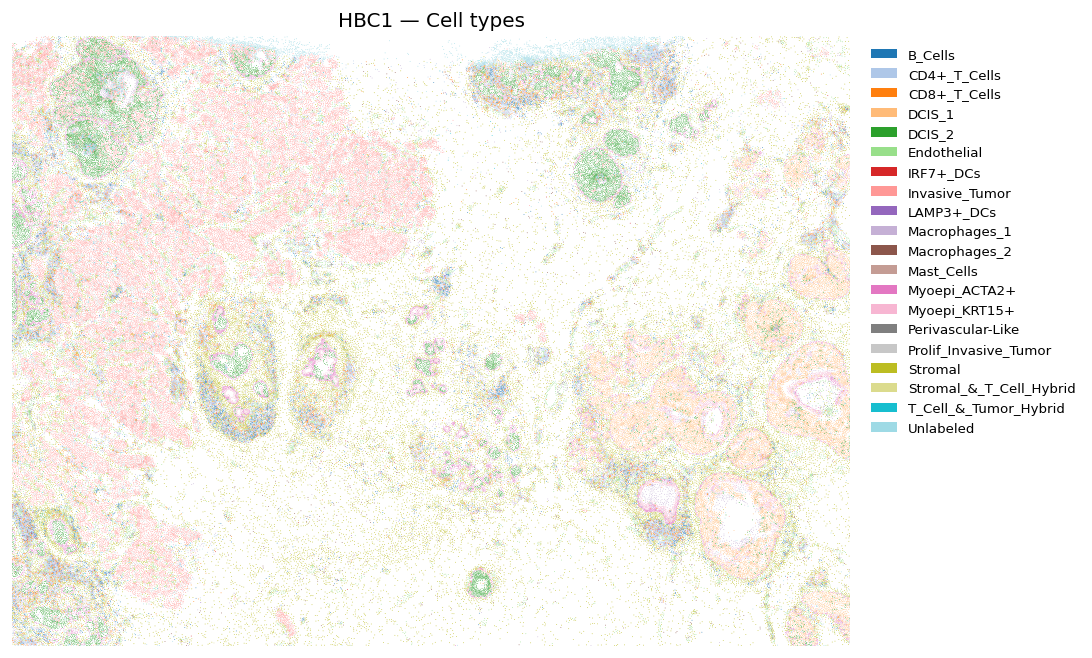

In [6]:
legend=[Patch(facecolor=type_colors[j],label=name)
        for j,name in enumerate(label_categories)]
save_spatial(type_colors[cell_type],'HBC1 — Cell types','HBC1_cell_types.png',legend)


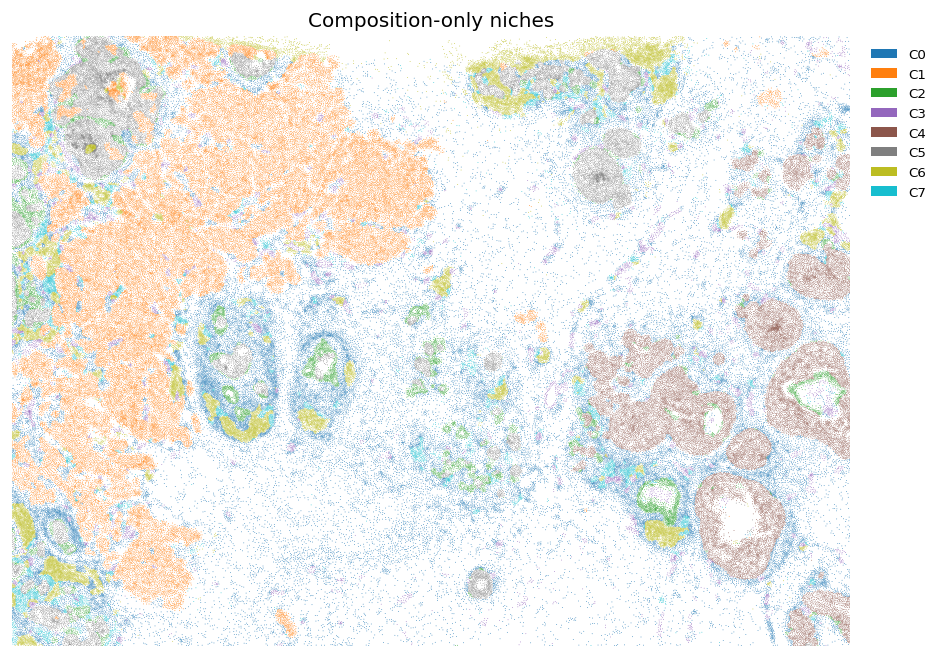

In [7]:
legend=[Patch(facecolor=single_colors[j],label=f'C{j}') for j in range(K_NICHE)]
save_spatial(single_colors[c_labels],'Composition-only niches',
             'HBC1_composition_only.png',legend)


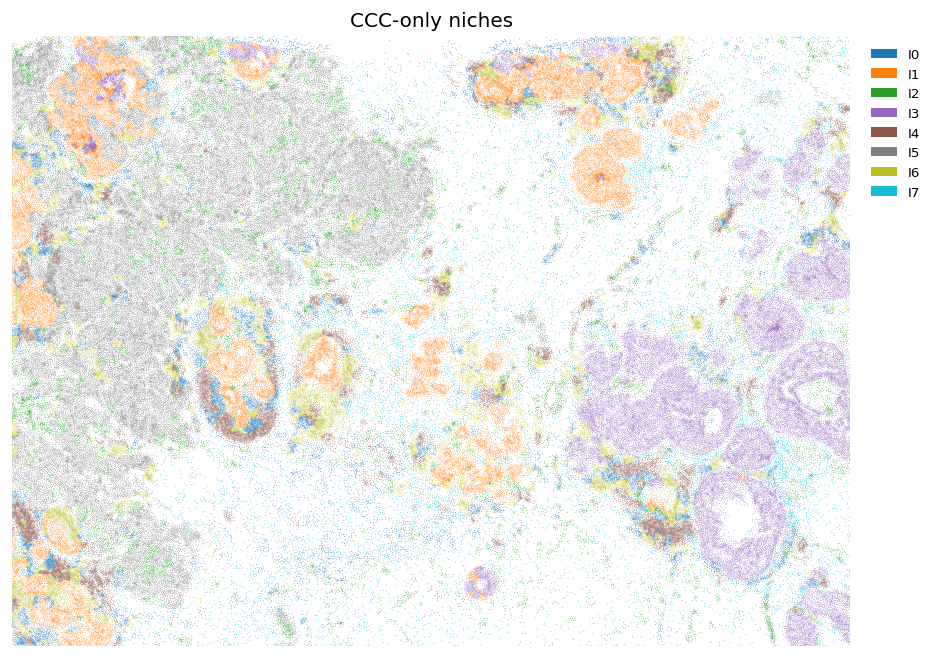

In [8]:
legend=[Patch(facecolor=single_colors[j],label=f'I{j}') for j in range(K_NICHE)]
save_spatial(single_colors[i_labels],'CCC-only niches','HBC1_CCC_only.png',legend)


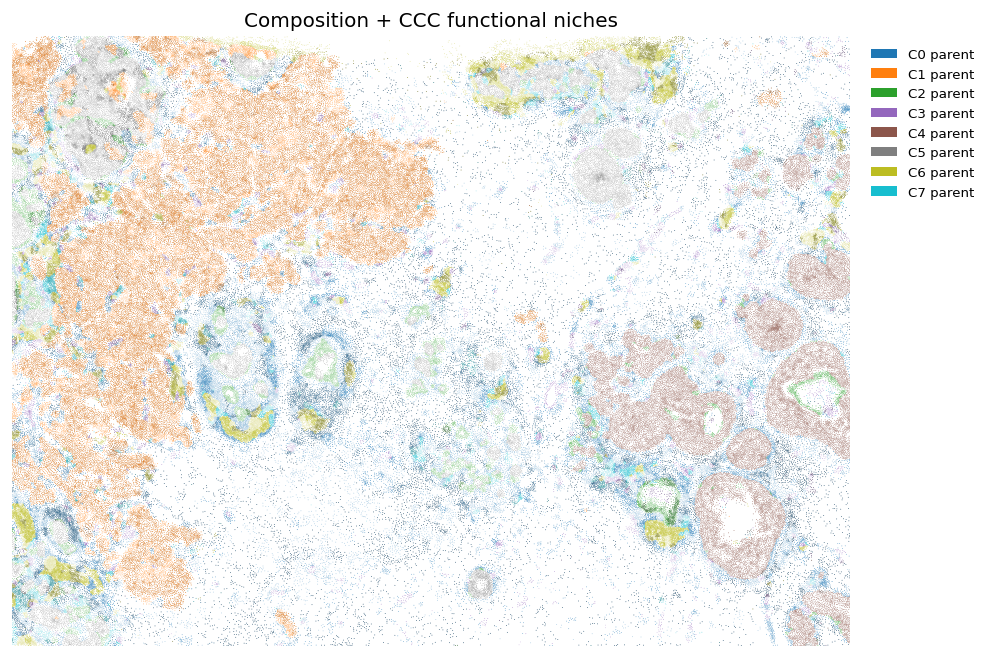

In [9]:
# One parent color family per C state; the I label changes only its shade.
legend=[Patch(facecolor=single_colors[j],label=f'C{j} parent') for j in range(K_NICHE)]
save_spatial(joint_rgb,'Composition + CCC functional niches',
             'HBC1_joint_hierarchical.png',legend)


## Niche–cell-type enrichment heatmaps

The layout follows the supplied example: niche rows × annotated cell-type columns, a 0–1 yellow–brown enrichment heatmap, significance stars **inside** the cells, and one blue entropy dot **above each cell-type column**. Columns are sorted by dot size from largest to smallest (left to right) within each heatmap. For each type, the underlying per-cell quantity is its anchor-weighted proportion in the fixed 200 µm neighborhood (`C[:, t]`). The displayed 0–1 enrichment is `clip((mean within niche − HBC1-wide mean) / (1 − HBC1-wide mean), 0, 1)`; zero includes no positive enrichment. Top-dot size is normalized Shannon entropy of that type’s weighted abundance **across the plotted niches**; larger means more widely distributed.

Stars are shown only for positive relative enrichment and use a **one-sided Mann–Whitney U test** of the local type proportion inside versus outside that niche (`greater`; raw `*` p≤0.05, `**` p≤0.001, `***` p≤0.0001). No multiple-testing correction is applied to displayed stars. This is a stated HBC1 adaptation of the visual layout, not a claim that the source paper used identical effect-size or entropy calculations. Spatially overlapping neighborhoods make these exploratory cell-level p-values.

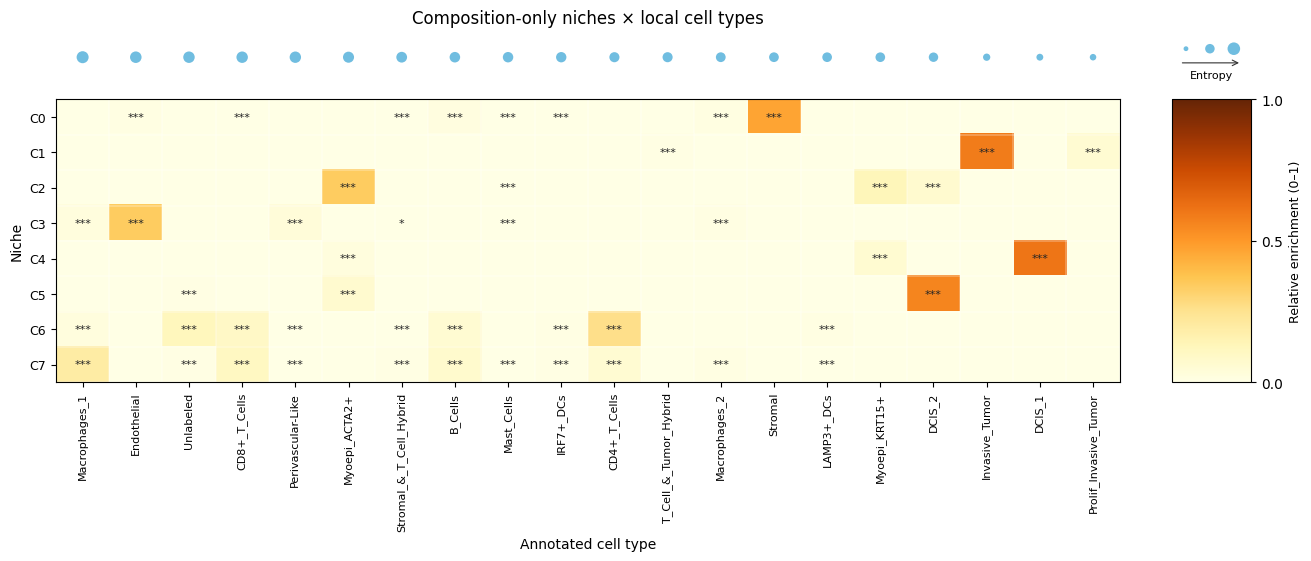

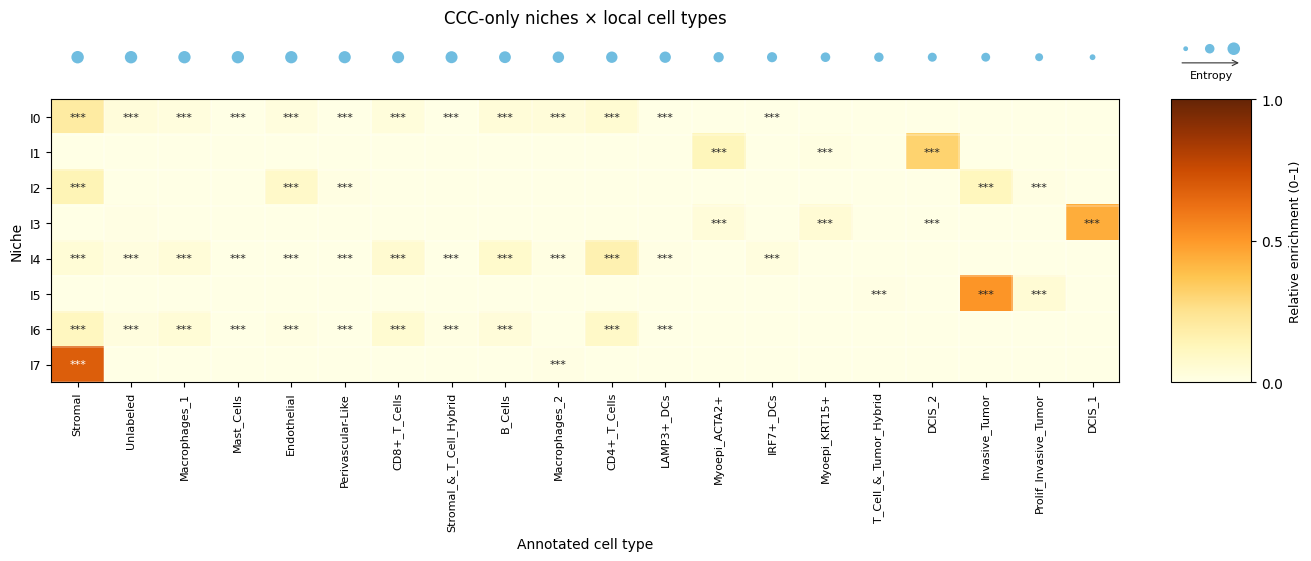

In [10]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import anndata as ad
import matplotlib.pyplot as plt
from scipy.stats import rankdata, tiecorrect, norm, mannwhitneyu

heatmap_dir = Path('/home/xueshuailin/CCC_Phe/V1004/outputs/hbc1_hierarchical_niches_r200')
heatmap_cells = pd.read_csv(heatmap_dir / 'cell_states.csv',
                            usecols=['cell_id', 'cell_type', 'C_state', 'I_state'],
                            dtype={'cell_id': str})
assert heatmap_cells.cell_id.is_unique
source_dir = Path('/home/xueshuailin/CCC_Phe/V1004/src')
if str(source_dir) not in sys.path:
    sys.path.insert(0, str(source_dir))
from phenoniche.v1004.radius_context import build_radius_context, radius_composition

# Rebuild only the original composition view; the NMF and CCC model are unchanged.
adata_local = ad.read_h5ad('/data1/xueshuailin/CCC_Phe_Niche/data/Xenium_HBC1/processed/HBC1_Xenium_processed.h5ad')
assert np.array_equal(adata_local.obs.cell_id.to_numpy(), heatmap_cells.cell_id.to_numpy())
heatmap_types = sorted(adata_local.obs.cell_type_coarse.unique())
assert set(heatmap_types) == set(heatmap_cells.cell_type.unique())
type_codes = pd.Categorical(adata_local.obs.cell_type_coarse, categories=heatmap_types).codes
context_local = build_radius_context(adata_local.obsm['spatial'].astype(np.float32),
                                     radius_um=200.0, anchor_sigma_um=20.0)
local_composition = radius_composition(context_local, type_codes, len(heatmap_types))
del context_local, adata_local
assert local_composition.shape == (len(heatmap_cells), len(heatmap_types))
assert np.allclose(local_composition.sum(axis=1), 1, atol=1e-5)
local_composition = local_composition.astype(np.float64)
n_cells, n_types = local_composition.shape
local_entropy = -np.sum(np.where(local_composition > 0,
                                  local_composition * np.log(np.maximum(local_composition, 1e-300)),
                                  0.0), axis=1) / np.log(n_types)
local_entropy = np.clip(local_entropy, 0.0, 1.0)  # Remove float32 rounding outside [0, 1].
assert np.isfinite(local_entropy).all()

# Global ranks let each niche-vs-rest test reproduce the asymptotic, tie-corrected
# one-sided Mann–Whitney U calculation without sorting the same column repeatedly.
def enrichment_table(niche_col, order, labels):
    group = pd.Categorical(heatmap_cells[niche_col], categories=order, ordered=True).codes
    assert (group >= 0).all()
    n_group = np.bincount(group, minlength=len(order)).astype(np.int64)
    assert (n_group > 0).all() and (n_group < n_cells).all()
    baseline = local_composition.mean(axis=0)
    records = []
    for t, type_name in enumerate(heatmap_types):
        values = local_composition[:, t]
        ranks = rankdata(values, method='average')
        tie_factor = tiecorrect(ranks)
        rank_sum = np.bincount(group, weights=ranks, minlength=len(order))
        abundance = np.bincount(group, weights=values, minlength=len(order))
        weighted_entropy = np.bincount(group, weights=values * local_entropy,
                                       minlength=len(order))
        n_out = n_cells - n_group
        u = rank_sum - n_group * (n_group + 1) / 2
        mean_u = n_group * n_out / 2
        sd_u = np.sqrt(n_group * n_out * (n_cells + 1) * tie_factor / 12)
        p = norm.sf((u - mean_u - 0.5) / sd_u) if tie_factor > 0 else np.ones(len(order))
        for k, niche_label in enumerate(labels):
            local_mean = abundance[k] / n_group[k]
            records.append({
                'niche': niche_label, 'cell_type': type_name, 'n_cells': int(n_group[k]),
                'mean_local_fraction': local_mean, 'global_mean_local_fraction': baseline[t],
                'log2_relative_enrichment': np.log2((local_mean + 1e-12) / (baseline[t] + 1e-12)),
                'local_celltype_entropy': weighted_entropy[k] / abundance[k] if abundance[k] > 0 else 0.0,
                'mannwhitney_u': u[k], 'p_greater_raw': p[k]
            })
    return pd.DataFrame.from_records(records)

# Check the vectorized test against SciPy on a representative tied composition column.
_test_mask = heatmap_cells.C_state.to_numpy() == 0
_test_type = 0
_scipy_p = mannwhitneyu(local_composition[_test_mask, _test_type],
                        local_composition[~_test_mask, _test_type],
                        alternative='greater', method='asymptotic').pvalue
_check = enrichment_table('C_state', sorted(heatmap_cells.C_state.unique()),
                          [f'C{k}' for k in sorted(heatmap_cells.C_state.unique())])
assert np.isclose(_check.iloc[_test_type].p_greater_raw, _scipy_p, atol=1e-7)

def enrichment_heatmap(stats, title, filename):
    niches = list(dict.fromkeys(stats.niche))
    types = list(dict.fromkeys(stats.cell_type))
    abundance = stats.pivot(index='niche', columns='cell_type', values='mean_local_fraction').loc[niches, types].to_numpy()
    baseline = stats.groupby('cell_type', sort=False).global_mean_local_fraction.first().loc[types].to_numpy()
    enrichment = np.clip((abundance - baseline[None, :]) /
                         np.maximum(1 - baseline[None, :], 1e-12), 0, 1)
    pvalues = stats.pivot(index='niche', columns='cell_type', values='p_greater_raw').loc[niches, types].to_numpy()
    sizes = stats.groupby('niche', sort=False).n_cells.first().loc[niches].to_numpy()
    type_mass = sizes[:, None] * abundance
    type_share = type_mass / np.maximum(type_mass.sum(axis=0, keepdims=True), 1e-12)
    entropy = -np.sum(np.where(type_share > 0, type_share * np.log(np.maximum(type_share, 1e-300)), 0),
                      axis=0) / np.log(len(niches))
    assert np.isfinite(enrichment).all() and np.isfinite(entropy).all()
    # Largest top-row entropy dots first, with stable tie handling.
    column_order = np.argsort(-entropy, kind='stable')
    types = [types[j] for j in column_order]
    enrichment = enrichment[:, column_order]
    pvalues = pvalues[:, column_order]
    entropy = entropy[column_order]
    assert np.all(np.diff(entropy) <= 1e-12)
    stats['relative_enrichment_0to1'] = np.clip(
        (stats.mean_local_fraction - stats.global_mean_local_fraction) /
        np.maximum(1 - stats.global_mean_local_fraction, 1e-12), 0, 1)
    stats['across_niche_entropy'] = stats.cell_type.map(dict(zip(types, entropy)))

    fig_height = max(5.5, 2.3 + 0.33 * len(niches))
    fig = plt.figure(figsize=(13, fig_height), layout='constrained')
    grid = fig.add_gridspec(2, 2, width_ratios=[20, 1.5],
                            height_ratios=[0.8, max(4, 0.38 * len(niches))],
                            hspace=0.02, wspace=0.08)
    ax = fig.add_subplot(grid[1, 0])
    top = fig.add_subplot(grid[0, 0], sharex=ax)
    bar_ax = fig.add_subplot(grid[1, 1])
    legend_ax = fig.add_subplot(grid[0, 1])

    image = ax.imshow(enrichment, cmap='YlOrBr', vmin=0, vmax=1,
                      aspect='auto', interpolation='nearest')
    for row, col in np.ndindex(enrichment.shape):
        if enrichment[row, col] <= 0:
            continue
        pvalue = pvalues[row, col]
        stars = '***' if pvalue <= 1e-4 else '**' if pvalue <= 1e-3 else '*' if pvalue <= .05 else ''
        if stars:
            ax.text(col, row, stars, ha='center', va='center',
                    fontsize=5 if len(niches) > 20 else 8,
                    color='white' if enrichment[row, col] > .65 else '#252525')
    ax.set_xticks(np.arange(len(types)), types, rotation=90, ha='center', fontsize=8)
    ax.set_yticks(np.arange(len(niches)), niches, fontsize=7 if len(niches) > 20 else 9)
    ax.set(xlabel='Annotated cell type', ylabel='Niche')
    ax.set_xticks(np.arange(-.5, len(types), 1), minor=True)
    ax.set_yticks(np.arange(-.5, len(niches), 1), minor=True)
    ax.grid(which='minor', color='white', linewidth=.35)
    ax.tick_params(which='minor', bottom=False, left=False)

    top.scatter(np.arange(len(types)), np.zeros(len(types)), s=12 + 70 * entropy,
                color='#70bde0', linewidths=0)
    top.set_ylim(-.5, .5)
    top.set_xlim(-.5, len(types) - .5)
    top.set_axis_off()
    top.set_title(title, fontsize=12, pad=4)
    bar = fig.colorbar(image, cax=bar_ax)
    bar.set_label('Relative enrichment (0–1)', fontsize=9)
    bar.set_ticks([0, .5, 1])

    legend_ax.set_xlim(0, 1)
    legend_ax.set_ylim(0, 1)
    legend_ax.scatter([.18, .48, .78], [.65] * 3,
                      s=[12 + 70 * value for value in (0, .5, 1)],
                      color='#70bde0', linewidths=0)
    legend_ax.annotate('', xy=(.88, .4), xytext=(.1, .4),
                       arrowprops=dict(arrowstyle='->', lw=.8, color='#333333'))
    legend_ax.text(.5, .12, 'Entropy', ha='center', fontsize=8)
    legend_ax.set_axis_off()
    fig.savefig(heatmap_dir / filename, dpi=220, bbox_inches='tight')
    plt.show()

for col, prefix, title, image_file, csv_file in (
    ('C_state', 'C', 'Composition-only niches × local cell types',
     'HBC1_composition_celltype_heatmap.png', 'HBC1_composition_celltype_enrichment.csv'),
    ('I_state', 'I', 'CCC-only niches × local cell types',
     'HBC1_CCC_celltype_heatmap.png', 'HBC1_CCC_celltype_enrichment.csv')):
    states = sorted(heatmap_cells[col].unique())
    labels = [f'{prefix}{state}' for state in states]
    stats = _check if col == 'C_state' else enrichment_table(col, states, labels)
    enrichment_heatmap(stats, title, image_file)
    stats.to_csv(heatmap_dir / csv_file, index=False)



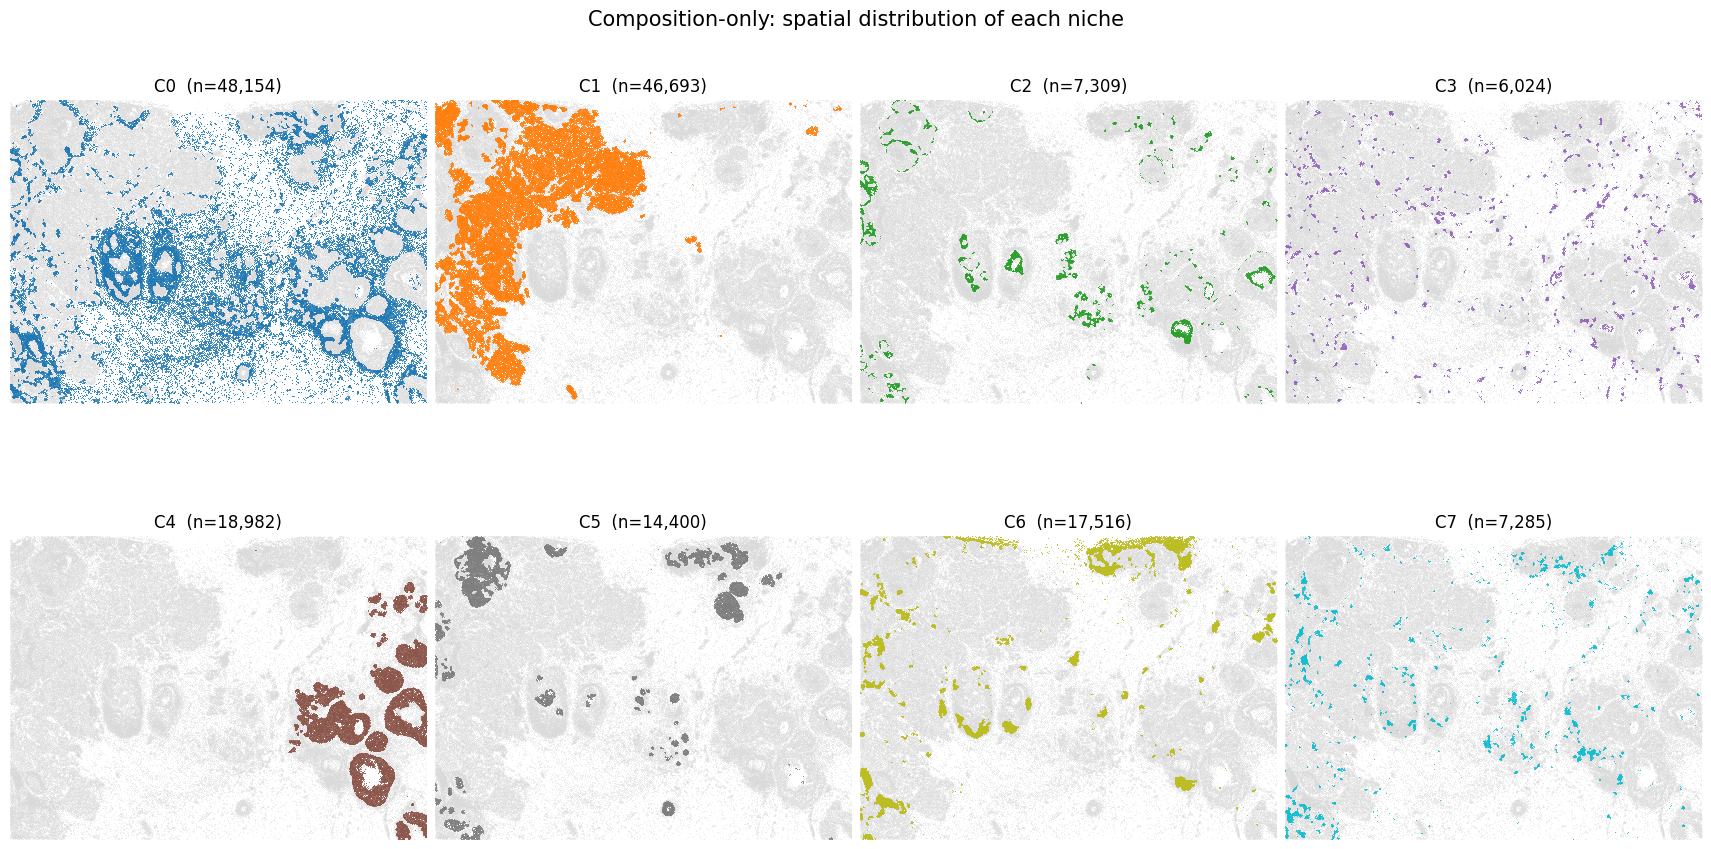

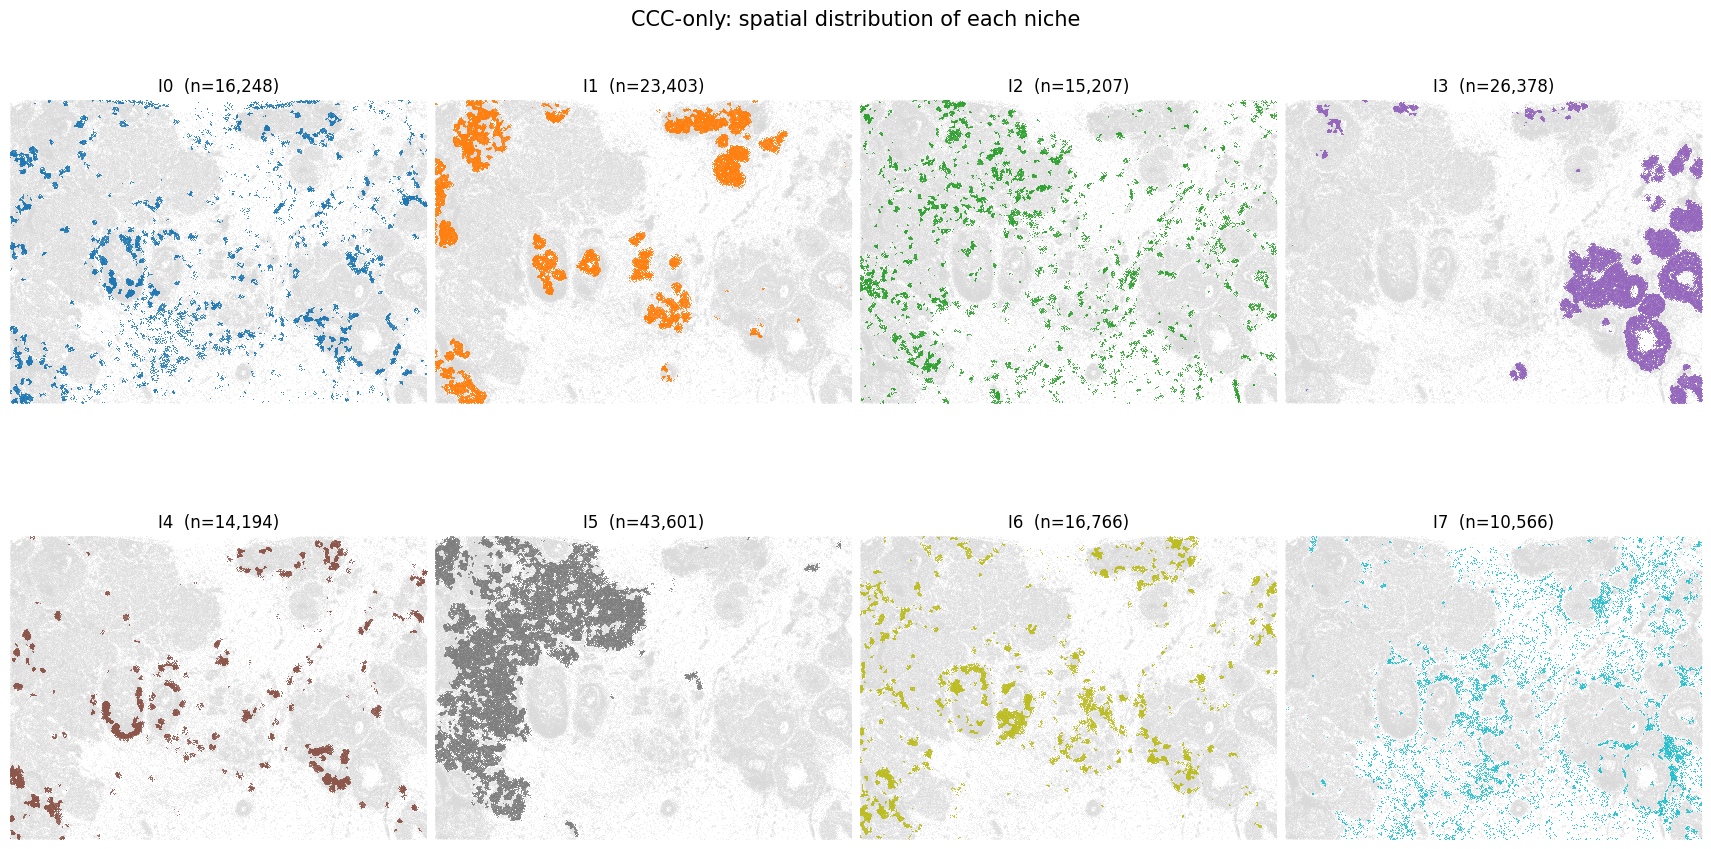

In [11]:
# Spatial distribution of each independently learned niche (the same cells and axes in every panel).
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

spatial_dir = Path('/home/xueshuailin/CCC_Phe/V1004/outputs/hbc1_hierarchical_niches_r200')
spatial_states = pd.read_csv(spatial_dir / 'cell_states.csv', usecols=['x', 'y', 'C_state', 'I_state'])
assert spatial_states[['x', 'y']].notna().all().all()
xy = spatial_states[['x', 'y']].to_numpy()
view_colors = plt.get_cmap('tab10', 8)(np.arange(8))
xlim = (xy[:, 0].min(), xy[:, 0].max())
ylim = (xy[:, 1].max(), xy[:, 1].min())  # Match the existing HBC1 maps.

def plot_each_niche(column, prefix, title, filename):
    labels = spatial_states[column].to_numpy()
    assert set(np.unique(labels)) == set(range(8))
    fig, axes = plt.subplots(2, 4, figsize=(17, 9), layout='constrained')
    for state, ax in enumerate(axes.flat):
        selected = labels == state
        ax.scatter(xy[:, 0], xy[:, 1], c='#d9d9d9', s=.16,
                   linewidths=0, rasterized=True)
        ax.scatter(xy[selected, 0], xy[selected, 1], c=[view_colors[state]],
                   s=.38, linewidths=0, rasterized=True)
        ax.set(xlim=xlim, ylim=ylim, title=f'{prefix}{state}  (n={selected.sum():,})')
        ax.set_aspect('equal')
        ax.set_axis_off()
    fig.suptitle(title, fontsize=15)
    fig.savefig(spatial_dir / filename, dpi=220, bbox_inches='tight')
    plt.show()

plot_each_niche('C_state', 'C', 'Composition-only: spatial distribution of each niche',
                'HBC1_composition_each_niche.png')
plot_each_niche('I_state', 'I', 'CCC-only: spatial distribution of each niche',
                'HBC1_CCC_each_niche.png')
